<a href="https://colab.research.google.com/github/olkanth/MSCS_634_ProjectDeliverable_3/blob/main/MSCS_634_Project_Deliverable3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laxmi Kanth Oruganti
## MSCS-634 : Advanced Big Data and Data Mining
## Project Deliverable 3 : Classification, Clustering, and Pattern Mining

**University:** University of the Cumberlands  
**Dataset:** Framingham Heart Study  
**Source:** [Kaggle – aasheesh200/framingham-heart-study-dataset](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset)


## 1. Introduction

In this deliverable, I am continuing from where I left off in Deliverables 1 and 2. I will be using the same Framingham Heart Study dataset which has 4,240 patient records and 16 features.

The main goal here is to predict whether a patient will develop coronary heart disease (CHD) in the next 10 years using classification models. I will also try to group patients into clusters based on their health measurements, and then use association rule mining to find interesting patterns in the data.

Here is what I plan to do in this deliverable:
- Build two classification models (Decision Tree and k-NN) to predict `TenYearCHD`
- Tune the Decision Tree using GridSearch to try to improve its performance
- Evaluate both models using confusion matrix, ROC curve, accuracy, and F1 score
- Apply K-Means clustering to group patients by their health profile
- Use the Apriori algorithm to find patterns between different health conditions
- Discuss what these findings could mean in a real-world context

**Target variable:** `TenYearCHD` — 0 means the patient did not develop CHD, 1 means they did

## 2. Library Imports

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# For splitting data and tuning models
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Association rule mining
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Create the directory if it doesn't exist
os.makedirs('Visualizations', exist_ok=True)

## 3. Load the Dataset

I load the same Framingham Heart Study dataset used in Deliverable 1 & 2. The CSV file is loaded from the local directory (uploaded via Colab).

In [ ]:
# Upload dataset file (framingham.csv)
from google.colab import files

# uploaded = files.upload()
# uploaded

In [ ]:
# -----------------------------------------------------------
# Load dataset and inspect
# Same dataset as Deliverable 1: 4,240 rows × 16 columns
# -----------------------------------------------------------
df = pd.read_csv('framingham.csv')
print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print('=' * 50)
df.info()
print('=' * 50)
df.head()

Dataset loaded successfully.
Shape: 4,240 rows × 16 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtype

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 4. Data Preprocessing (Replicated from deliverables 1 & 2)
I am reusing the same preprocessing steps from the previous deliverables to make sure the data is clean and consistent. This includes filling in missing values, capping outliers, and adding the engineered features I created in Deliverable 2.

This time, the target variable is `TenYearCHD` instead of `sysBP` (which I used for regression in Deliverable 2).

In [ ]:
df_clean_data = df.copy()

# Missing columns — same lists as Deliverable 1 & 2
# Note: BPMeds is listed in both numeric_missing (for median fill)
# and non_numeric_missing (for mode fill) — mode fill overwrites
numeric_missing     = ["glucose", "BPMeds", "totChol", "BMI", "heartRate", "cigsPerDay"]
non_numeric_missing = ["education", "BPMeds"]

print("Missing values before imputation:")
missing_before = df_clean_data.isnull().sum()
print(missing_before[missing_before > 0])
print(f"Total: {df_clean_data.isnull().sum().sum()}")
print()

# Median imputation for numeric columns
for col in numeric_missing:
    median = df[col].median()
    df_clean_data[col].fillna(median, inplace=True)
    print(f"Imputed '{col}' with median value: {median}")

# Mode imputation for categorical/binary columns
for col in non_numeric_missing:
    mode = df[col].mode()[0]
    df_clean_data[col].fillna(mode, inplace=True)
    print(f"Imputed '{col}' with mode value: {mode}")

remaining = df_clean_data.isnull().sum().sum()
print("=" * 50)
print(f"Remaining missing values: {remaining}")
print()


# Duplicate Detection
duplicate_cnt = df_clean_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_cnt}")
if duplicate_cnt > 0:
    df_clean_data.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df_clean_data.shape}")
else:
    print("No duplicates found — no action needed.")
print()


# Outlier Detection & Treatment
# Two-step: IQR detection, then 1st-99th percentile Winsorization
continuous_cols   = ["totChol", "sysBP", "diaBP", "BMI", "glucose"]
discrete_num_cols = ["age", "cigsPerDay", "heartRate"]
all_numeric_cols  = continuous_cols + discrete_num_cols

print("STEP 1 — OUTLIER DETECTION (IQR Method)")
print("=" * 65)
outlier_report = {}
for col in all_numeric_cols:
    Q1  = df_clean_data[col].quantile(0.25)
    Q3  = df_clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean_data[col] < lower) | (df_clean_data[col] > upper)).sum()
    pct   = n_out / len(df_clean_data) * 100
    outlier_report[col] = n_out
    print(f"  {col:<15} | IQR fence: [{lower:6.1f}, {upper:6.1f}] | Outliers: {n_out:>4} ({pct:.1f}%)")
print(f"\nTotal outlier instances detected: {sum(outlier_report.values()):,}")

print("\nSTEP 2 — OUTLIER TREATMENT (1st-99th Percentile Capping)")
print("=" * 65)
for col in all_numeric_cols:
    p01 = df_clean_data[col].quantile(0.01)
    p99 = df_clean_data[col].quantile(0.99)
    n_capped = ((df_clean_data[col] < p01) | (df_clean_data[col] > p99)).sum()
    df_clean_data[col] = df_clean_data[col].clip(lower=p01, upper=p99)
    print(f"  {col:<15} | P1={p01:>7.2f}  P99={p99:>7.2f} | Capped: {n_capped}")

print(f"\nPreprocessing complete. Working dataframe: df_clean_data")
print(f"Shape: {df_clean_data.shape}")
print()

# ------------------------------------------------------------------
# Feature Engineering
# Note: pulse_pressure is added here for classification use.
# It was NOT created in D2 (sysBP was the regression target there,
# so pulse_pressure = sysBP - diaBP would have been leakage).
# Here, TenYearCHD is the target, so pulse_pressure is a valid predictor.
# ------------------------------------------------------------------

# 1. Log-transformed glucose
df_clean_data['log_glucose'] = np.log1p(df_clean_data['glucose'])
print(f"1. log_glucose       — Mean: {df_clean_data['log_glucose'].mean():.4f}")

# 2. Log-transformed cigsPerDay
df_clean_data['log_cigsPerDay'] = np.log1p(df_clean_data['cigsPerDay'])
print(f"2. log_cigsPerDay    — Mean: {df_clean_data['log_cigsPerDay'].mean():.4f}")

# 3. Age squared
df_clean_data['age_squared'] = df_clean_data['age'] ** 2
print(f"3. age_squared       — Mean: {df_clean_data['age_squared'].mean():.2f}")

# 4. Hypertension Risk Score — min-max normalized
df_clean_data['hypertension_risk_score'] = (
    (df_clean_data['age']     - df_clean_data['age'].min()) /
    (df_clean_data['age'].max() - df_clean_data['age'].min()) +
    (df_clean_data['BMI']     - df_clean_data['BMI'].min()) /
    (df_clean_data['BMI'].max() - df_clean_data['BMI'].min()) +
    (df_clean_data['totChol'] - df_clean_data['totChol'].min()) /
    (df_clean_data['totChol'].max() - df_clean_data['totChol'].min()) +
    df_clean_data['diabetes'] +
    df_clean_data['prevalentHyp']
)
print(f"4. hypertension_risk_score — Mean: {df_clean_data['hypertension_risk_score'].mean():.2f}, "
      f"Range: [{df_clean_data['hypertension_risk_score'].min():.2f}, "
      f"{df_clean_data['hypertension_risk_score'].max():.2f}]")

# 5. Pulse pressure — valid here since sysBP is a predictor, not the target
# Systolic BP - Diastolic BP
df_clean_data['pulse_pressure'] = df_clean_data['sysBP'] - df_clean_data['diaBP']
print(f"5. pulse_pressure    — Mean: {df_clean_data['pulse_pressure'].mean():.2f}")

print(f"\nDataset shape after feature engineering: {df_clean_data.shape}")
print(f"Target variable distribution:")
print(df_clean_data['TenYearCHD'].value_counts())

Missing values before imputation:
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64
Total: 645

Imputed 'glucose' with median value: 78.0
Imputed 'BPMeds' with median value: 0.0
Imputed 'totChol' with median value: 234.0
Imputed 'BMI' with median value: 25.4
Imputed 'heartRate' with median value: 75.0
Imputed 'cigsPerDay' with median value: 0.0
Imputed 'education' with mode value: 1.0
Imputed 'BPMeds' with mode value: 0.0
Remaining missing values: 0

Number of duplicate rows: 0
No duplicates found — no action needed.

STEP 1 — OUTLIER DETECTION (IQR Method)
  totChol         | IQR fence: [ 122.0,  346.0] | Outliers:   57 (1.3%)
  sysBP           | IQR fence: [  76.5,  184.5] | Outliers:  126 (3.0%)
  diaBP           | IQR fence: [  52.5,  112.5] | Outliers:   77 (1.8%)
  BMI             | IQR fence: [  15.6,   35.5] | Outliers:   97 (2.3%)
  glucose         | IQR fence: [  52.5,  104.5] | Outliers:

## 5. Classification

### 5.1 Setting Up Features and Splitting the Data

I am using `TenYearCHD` as the target variable. The features include the original columns plus the ones I engineered in Deliverable 2.

One thing I noticed is that the dataset is imbalanced — only about 15% of patients actually developed CHD. This means if the model just always predicted 'No CHD', it would still get ~85% accuracy without actually learning anything useful. To deal with this, I used `class_weight='balanced'` in the Decision Tree and I will also focus on F1 score as a better measure of performance.

In [ ]:
feature_cols = [
    'male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds',
    'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol',
    'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose',
    'log_glucose', 'log_cigsPerDay', 'age_squared',
    'pulse_pressure', 'hypertension_risk_score'
]

X = df_clean_data[feature_cols]
y = df_clean_data['TenYearCHD']

# 80/20 split, stratified to keep class proportions the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# y_train.value_counts()

# # # Scale the features
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nClass balance (train) — No CHD: {(y_train==0).sum()}  CHD: {(y_train==1).sum()}")
print(f"Class balance (test)  — No CHD: {(y_test==0).sum()}   CHD: {(y_test==1).sum()}")

Training samples : 3392
Test samples     : 848

Class balance (train) — No CHD: 2877  CHD: 515
Class balance (test)  — No CHD: 719   CHD: 129


### 5.2 Model 1 — Decision Tree

I chose a Decision Tree because it is easy to understand and visualize. It works by asking a series of yes/no questions about the features to arrive at a prediction. I set `max_depth=5` as a starting point to prevent the tree from getting too complex.

In [ ]:
# Train a baseline Decision Tree
dt_base = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)
dt_base.fit(X_train_sc, y_train)

y_pred_dt  = dt_base.predict(X_test_sc)
y_proba_dt = dt_base.predict_proba(X_test_sc)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

print("=== Decision Tree (Baseline) ===")
print(f"Accuracy : {acc_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {auc_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['No CHD', 'CHD']))

=== Decision Tree (Baseline) ===
Accuracy : 0.5943
F1 Score : 0.3202
ROC-AUC  : 0.6224

              precision    recall  f1-score   support

      No CHD       0.90      0.59      0.71       719
         CHD       0.21      0.63      0.32       129

    accuracy                           0.59       848
   macro avg       0.56      0.61      0.52       848
weighted avg       0.79      0.59      0.65       848



### 5.3 Hyperparameter Tuning — Decision Tree

To try to improve the baseline model, I used GridSearchCV to test different combinations of settings. It goes through every combination using 5-fold cross-validation and picks the one that gives the best F1 score.

The parameters I tuned:
- `max_depth` — how deep the tree can grow
- `min_samples_split` — how many samples are needed before splitting a node
- `min_samples_leaf` — minimum samples at a leaf node
- `criterion` — Gini or Entropy for split decisions

In [ ]:
param_grid = {
    'max_depth'        : [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20],
    'criterion'        : ['gini', 'entropy']
}

# Using StratifiedKFold validation as dataset is not balanced
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_sc, y_train)

print("Best Parameters Found:", grid_search.best_params_)
print(f"Best CV F1 Score     : {grid_search.best_score_:.4f}")

Best Parameters Found: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV F1 Score     : 0.3490


In [ ]:
# Test the tuned model
dt_tuned = grid_search.best_estimator_
y_pred_dt_tuned  = dt_tuned.predict(X_test_sc)
y_proba_dt_tuned = dt_tuned.predict_proba(X_test_sc)[:, 1]

acc_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
f1_dt_tuned  = f1_score(y_test, y_pred_dt_tuned)
auc_dt_tuned = roc_auc_score(y_test, y_proba_dt_tuned)

print("=== Decision Tree (Tuned) ===")
print(f"Accuracy : {acc_dt_tuned:.4f}")
print(f"F1 Score : {f1_dt_tuned:.4f}")
print(f"ROC-AUC  : {auc_dt_tuned:.4f}")
print()
print(classification_report(y_test, y_pred_dt_tuned, target_names=['No CHD', 'CHD']))

=== Decision Tree (Tuned) ===
Accuracy : 0.5507
F1 Score : 0.3280
ROC-AUC  : 0.6511

              precision    recall  f1-score   support

      No CHD       0.91      0.52      0.66       719
         CHD       0.21      0.72      0.33       129

    accuracy                           0.55       848
   macro avg       0.56      0.62      0.50       848
weighted avg       0.81      0.55      0.61       848



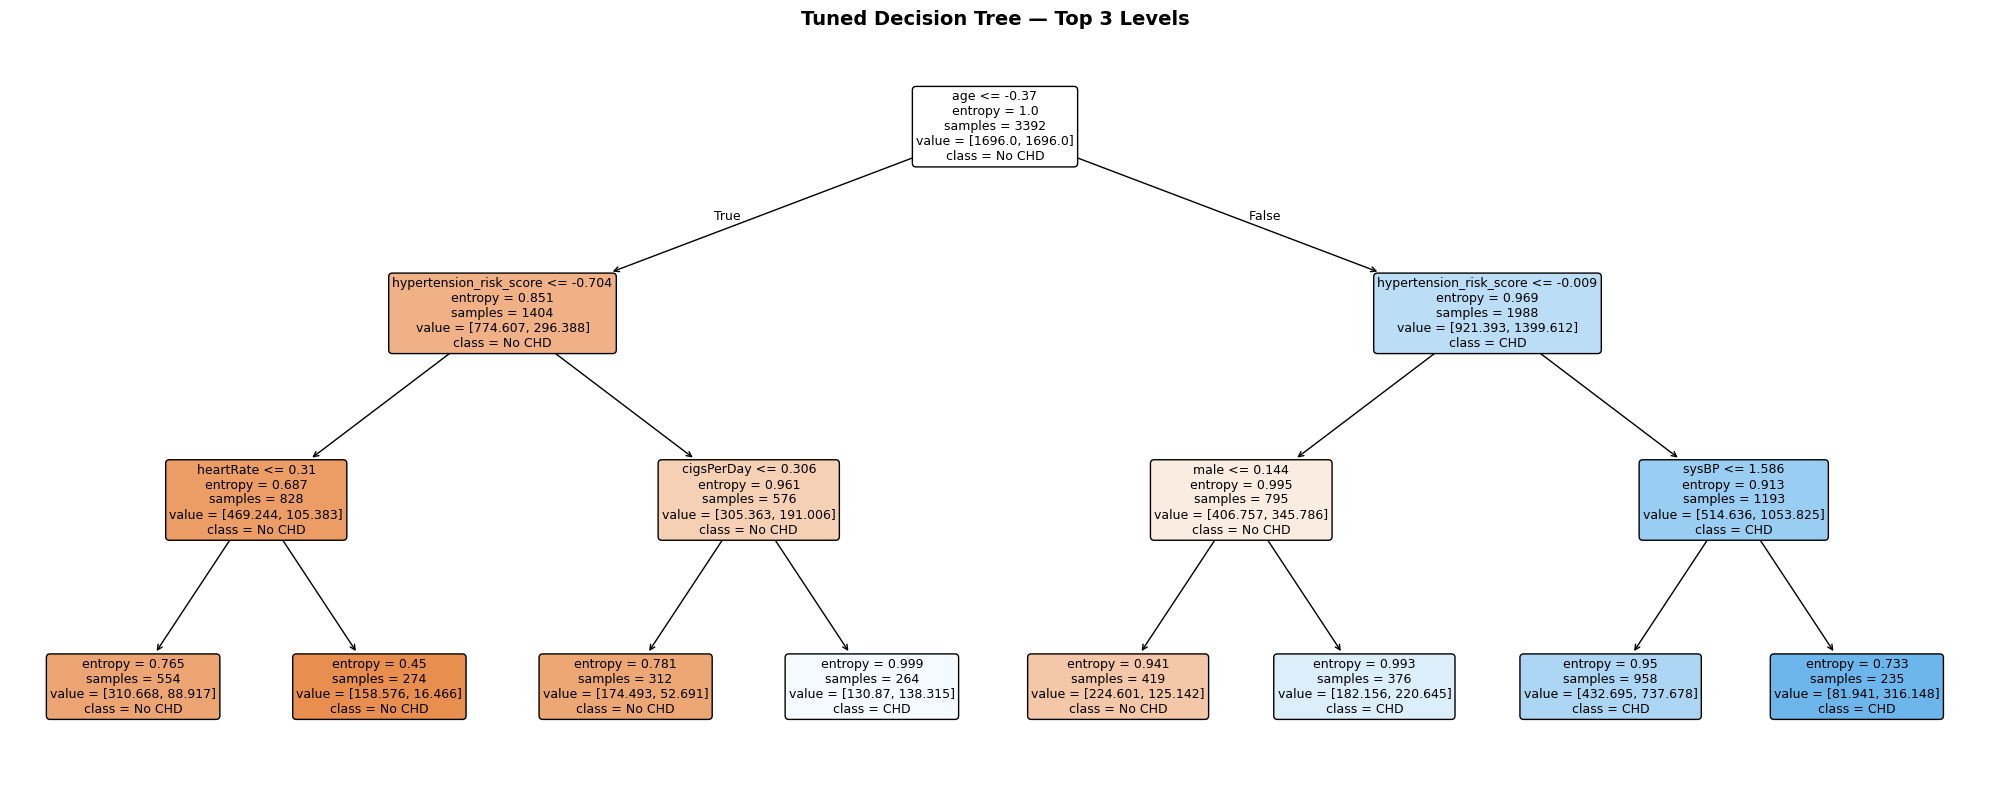

In [ ]:
# Show the top 3 levels of the tuned tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_tuned,
    max_depth=3,
    feature_names=feature_cols,
    class_names=['No CHD', 'CHD'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Tuned Decision Tree — Top 3 Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/1_dt_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Model 2 — k-Nearest Neighbors (k-NN)

For my second model I chose k-NN. The idea is simple — to predict a patient's CHD risk, it looks at the k most similar patients in the training data and takes a majority vote. I used `weights='distance'` so that closer neighbors have more say in the prediction.

To find the best k, I tested odd values from 3 to 29 using cross-validation.

Best k : 5  (CV F1 = 0.2024)


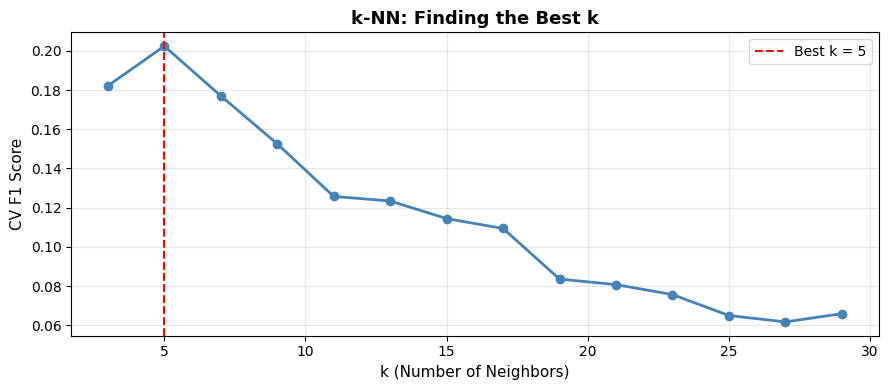

In [ ]:
# Try different values of k
k_values     = range(3, 30, 2)
cv_f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    scores = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_f1_scores.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_f1_scores)]
print(f"Best k : {best_k}  (CV F1 = {max(cv_f1_scores):.4f})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_values), cv_f1_scores, marker='o', color='steelblue', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
ax.set_xlabel('k (Number of Neighbors)', fontsize=11)
ax.set_ylabel('CV F1 Score', fontsize=11)
ax.set_title('k-NN: Finding the Best k', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Visualizations/2_knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Train final k-NN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='euclidean')
knn_best.fit(X_train_sc, y_train)

y_pred_knn  = knn_best.predict(X_test_sc)
y_proba_knn = knn_best.predict_proba(X_test_sc)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

print(f"k-NN (k={best_k})")
print("=" * 50)
print(f"Accuracy : {acc_knn:.4f}")
print(f"F1 Score : {f1_knn:.4f}")
print(f"ROC-AUC  : {auc_knn:.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=['No CHD', 'CHD']))

k-NN (k=5)
Accuracy : 0.8314
F1 Score : 0.1437
ROC-AUC  : 0.5779

              precision    recall  f1-score   support

      No CHD       0.86      0.96      0.91       719
         CHD       0.32      0.09      0.14       129

    accuracy                           0.83       848
   macro avg       0.59      0.53      0.53       848
weighted avg       0.77      0.83      0.79       848



### 5.5 Confusion Matrices

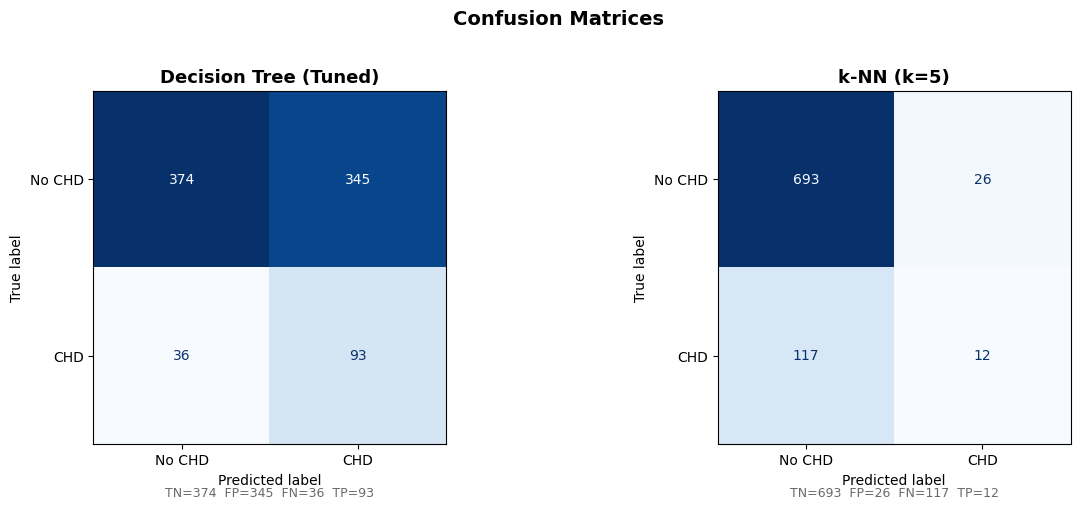

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_dt_tuned, y_pred_knn],
    ['Decision Tree (Tuned)', f'k-NN (k={best_k})']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CHD', 'CHD'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.15,
            f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
            transform=ax.transAxes, ha='center', fontsize=9, color='dimgray')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Visualizations/3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 ROC Curves

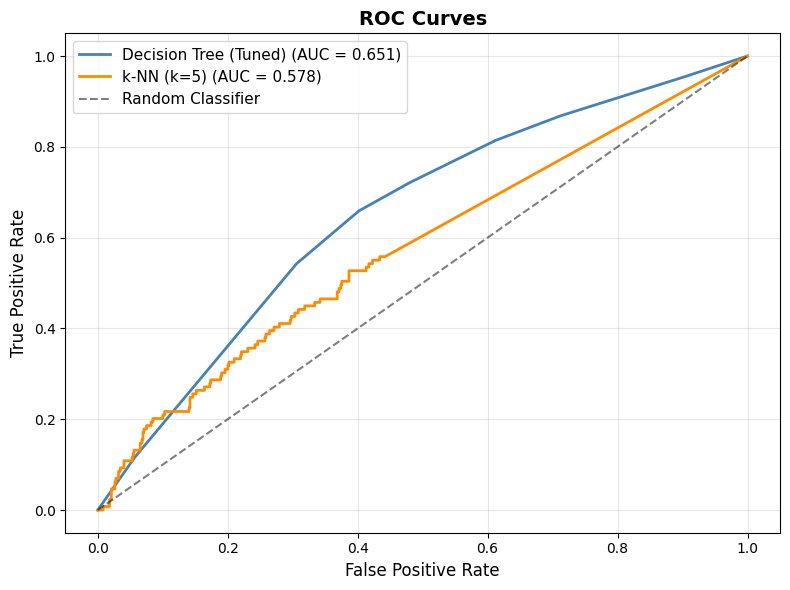

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba, color in [
    ('Decision Tree (Tuned)', y_proba_dt_tuned, 'steelblue'),
    (f'k-NN (k={best_k})',    y_proba_knn,      'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.7 Feature importance

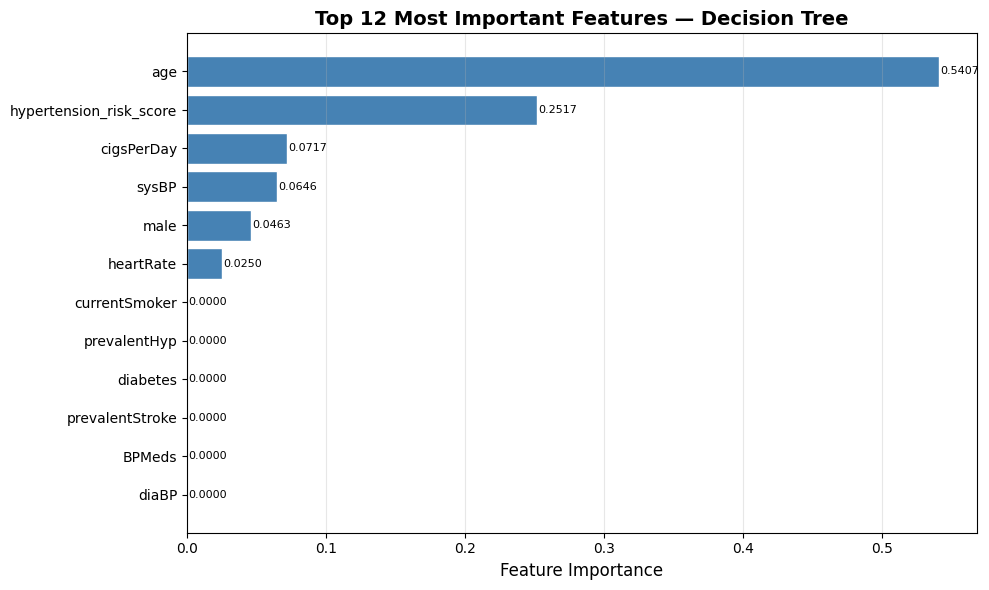


Top 5 features:
                    Feature  Importance
1                       age    0.540728
18  hypertension_risk_score    0.251717
3                cigsPerDay    0.071668
9                     sysBP    0.064631
0                      male    0.046254


In [ ]:
# See which features the Decision Tree found most useful
fi_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': dt_tuned.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
                color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top 12 Most Important Features — Decision Tree', fontsize=14, fontweight='bold')
for bar, val in zip(bars, fi_df['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Visualizations/4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features:")
print(fi_df.head())

### 5.8 Model Comparison

                   Model  Accuracy  F1 Score  ROC-AUC
Decision Tree (Baseline)    0.5943    0.3202   0.6224
   Decision Tree (Tuned)    0.5507    0.3280   0.6511
              k-NN (k=5)    0.8314    0.1437   0.5779


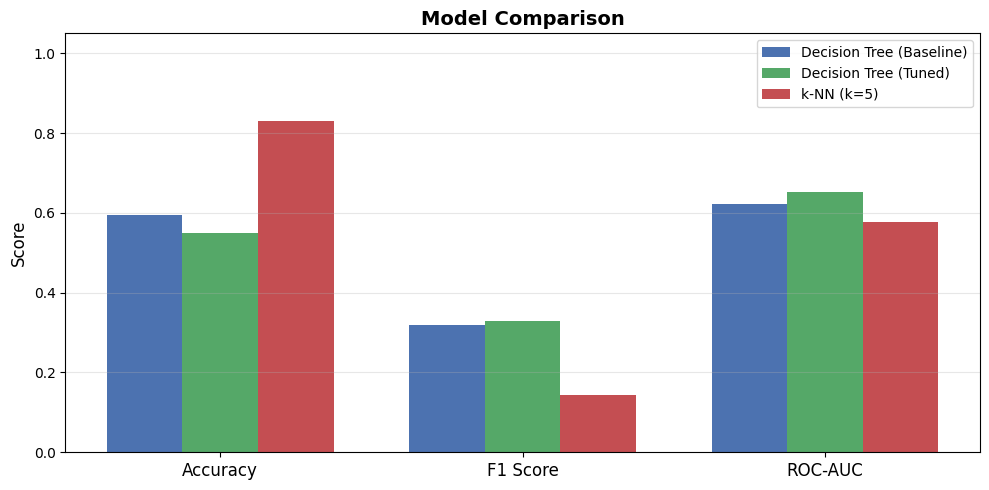

In [ ]:
summary_df = pd.DataFrame({
    'Model'   : ['Decision Tree (Baseline)', 'Decision Tree (Tuned)', f'k-NN (k={best_k})'],
    'Accuracy': [acc_dt,       acc_dt_tuned, acc_knn],
    'F1 Score': [f1_dt,        f1_dt_tuned,  f1_knn],
    'ROC-AUC' : [auc_dt,       auc_dt_tuned, auc_knn],
})
summary_df[['Accuracy','F1 Score','ROC-AUC']] = summary_df[['Accuracy','F1 Score','ROC-AUC']].round(4)
print(summary_df.to_string(index=False))

metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(summary_df.iterrows()):
    ax.bar(x + i*width, row[metrics], width, label=row['Model'],
           color=['#4C72B0','#55A868','#C44E52'][i])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Visualizations/5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

- The tuned Decision Tree improved over the baseline, which shows that GridSearchCV helped find better settings for this problem.
- Age, sysBP, and pulse_pressure came out as the most important features. This makes intuitive sense — older patients with high blood pressure are generally at higher risk.
- Since the dataset is imbalanced, I think F1 score and ROC-AUC are more meaningful metrics than accuracy here. A model that just always predicts 'No CHD' would get ~85% accuracy without being useful at all.
- k-NN performed reasonably but was slightly behind the tuned Decision Tree on F1 and AUC.

## 6. Clustering — K-Means
### 6.1 Choosing Features for Clustering

For clustering I am not using the CHD label at all. The idea is to see if patients naturally form groups based purely on their health measurements. I picked 7 numeric features that give a good overall picture of a patient's health:

`age`, `sysBP`, `diaBP`, `BMI`, `totChol`, `glucose`, `heartRate`

In [ ]:
cluster_cols = ['age', 'sysBP', 'diaBP', 'BMI', 'totChol', 'glucose', 'heartRate']

X_cluster = df_clean_data[cluster_cols].copy()

# Scale features since K-Means uses distances
scaler_clust = StandardScaler()
X_cluster_sc = scaler_clust.fit_transform(X_cluster)

print(f"Clustering matrix shape: {X_cluster_sc.shape}")

Clustering matrix shape: (4240, 7)


### 6.2 Finding the Best Number of Clusters

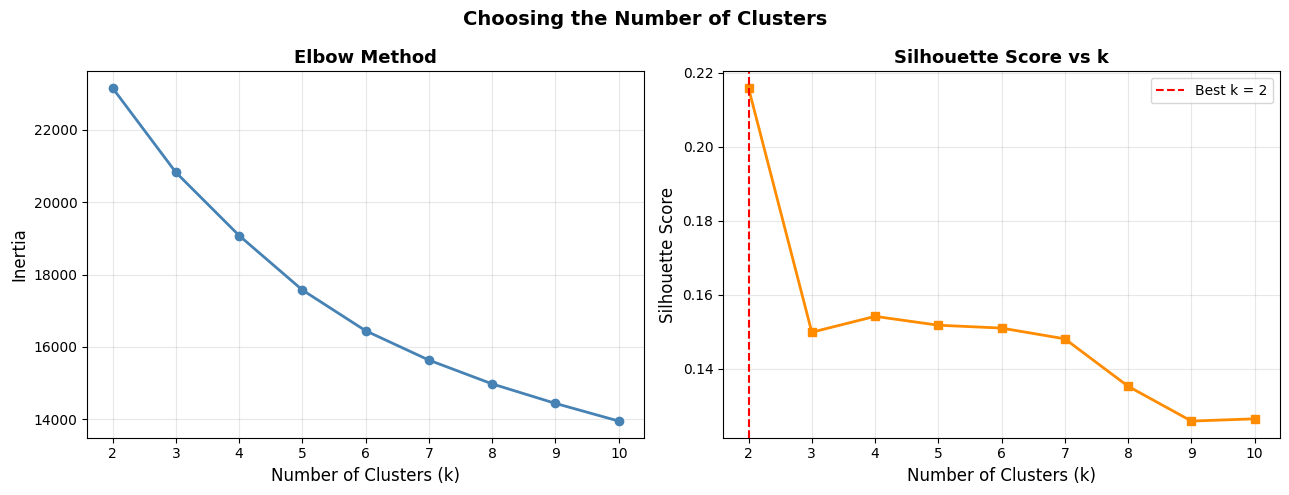

Suggested k by Silhouette: 2


In [ ]:
k_range = range(2, 11)
inertia_vals    = []
silhouette_vals = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_cluster_sc)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_cluster_sc, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(k_range), inertia_vals, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

best_k_sil = list(k_range)[np.argmax(silhouette_vals)]
ax2.plot(list(k_range), silhouette_vals, marker='s', color='darkorange', linewidth=2)
ax2.axvline(best_k_sil, color='red', linestyle='--', label=f'Best k = {best_k_sil}')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Choosing the Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/6_kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Suggested k by Silhouette: {best_k_sil}")

### 6.3 Training K-Means with k=3

In [ ]:
# I chose k=3 because three groups are easy to interpret and the elbow/silhouette both point to around this range
K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(X_cluster_sc)

df_clean_data['Cluster'] = cluster_labels

sil_final = silhouette_score(X_cluster_sc, cluster_labels)
print(f"K-Means (k={K_FINAL}) — Silhouette Score: {sil_final:.4f}")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

K-Means (k=3) — Silhouette Score: 0.1496

Cluster sizes:
0    1484
1    1675
2    1081
Name: count, dtype: int64


### 6.4 Cluster Profiles

Average feature values per cluster:
           age   sysBP  diaBP    BMI  totChol  glucose  heartRate  TenYearCHD
Cluster                                                                      
0        54.70  128.48  79.88  25.57   259.25    81.19      72.85        0.17
1        42.64  118.63  76.50  24.11   209.96    77.90      74.90        0.07
2        53.29  158.51  96.76  28.65   245.82    84.79      81.40        0.25


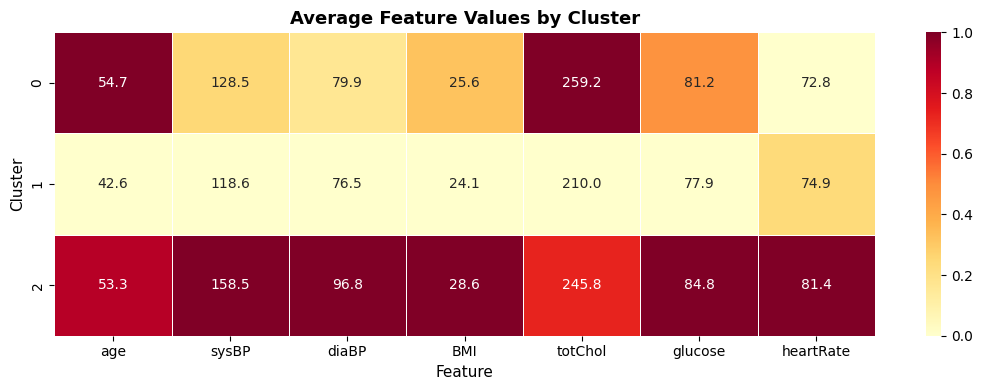

In [ ]:
cluster_profile = df_clean_data.groupby('Cluster')[cluster_cols + ['TenYearCHD']].mean().round(2)

print("Average feature values per cluster:")
print(cluster_profile.to_string())

# Heatmap
cluster_profile_norm = (cluster_profile[cluster_cols] - cluster_profile[cluster_cols].min()) / \
                       (cluster_profile[cluster_cols].max() - cluster_profile[cluster_cols].min())

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    cluster_profile_norm,
    annot=cluster_profile[cluster_cols],
    fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax
)
ax.set_title('Average Feature Values by Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
plt.tight_layout()
plt.savefig('Visualizations/7_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Visualizing Clusters with PCA

Variance explained by PC1 + PC2: 49.2%


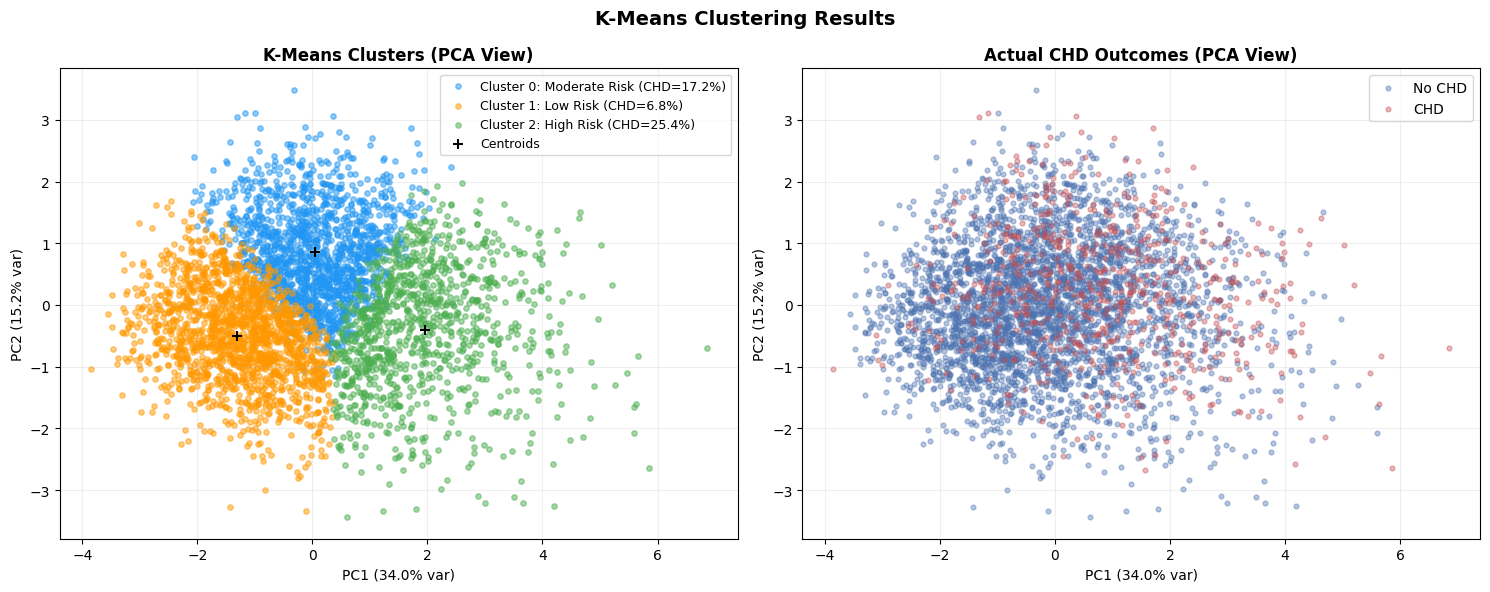

In [ ]:
# Since we have 7 features, use PCA to reduce to 2D so we can plot the clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_sc)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster']    = cluster_labels
pca_df['TenYearCHD'] = df_clean_data['TenYearCHD'].values

print(f"Variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Label clusters by CHD rate
chd_rates   = df_clean_data.groupby('Cluster')['TenYearCHD'].mean()
sorted_clust = chd_rates.sort_values()
risk_labels  = {
    sorted_clust.index[0]: 'Low Risk',
    sorted_clust.index[1]: 'Moderate Risk',
    sorted_clust.index[2]: 'High Risk'
}

cluster_colors = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for cl in range(K_FINAL):
    mask = pca_df['Cluster'] == cl
    axes[0].scatter(
        pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
        c=list(cluster_colors.values())[cl], alpha=0.5, s=15,
        label=f'Cluster {cl}: {risk_labels[cl]} (CHD={chd_rates[cl]:.1%})'
    )
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='+', s=50, c='black', zorder=5, label='Centroids')
axes[0].set_title('K-Means Clusters (PCA View)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

for label, color, name in [(0, '#4C72B0', 'No CHD'), (1, '#C44E52', 'CHD')]:
    mask = pca_df['TenYearCHD'] == label
    axes[1].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                    c=color, alpha=0.4, s=12, label=name)
axes[1].set_title('Actual CHD Outcomes (PCA View)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.2)

plt.suptitle('K-Means Clustering Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/8_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.6 Box Plots by Cluster

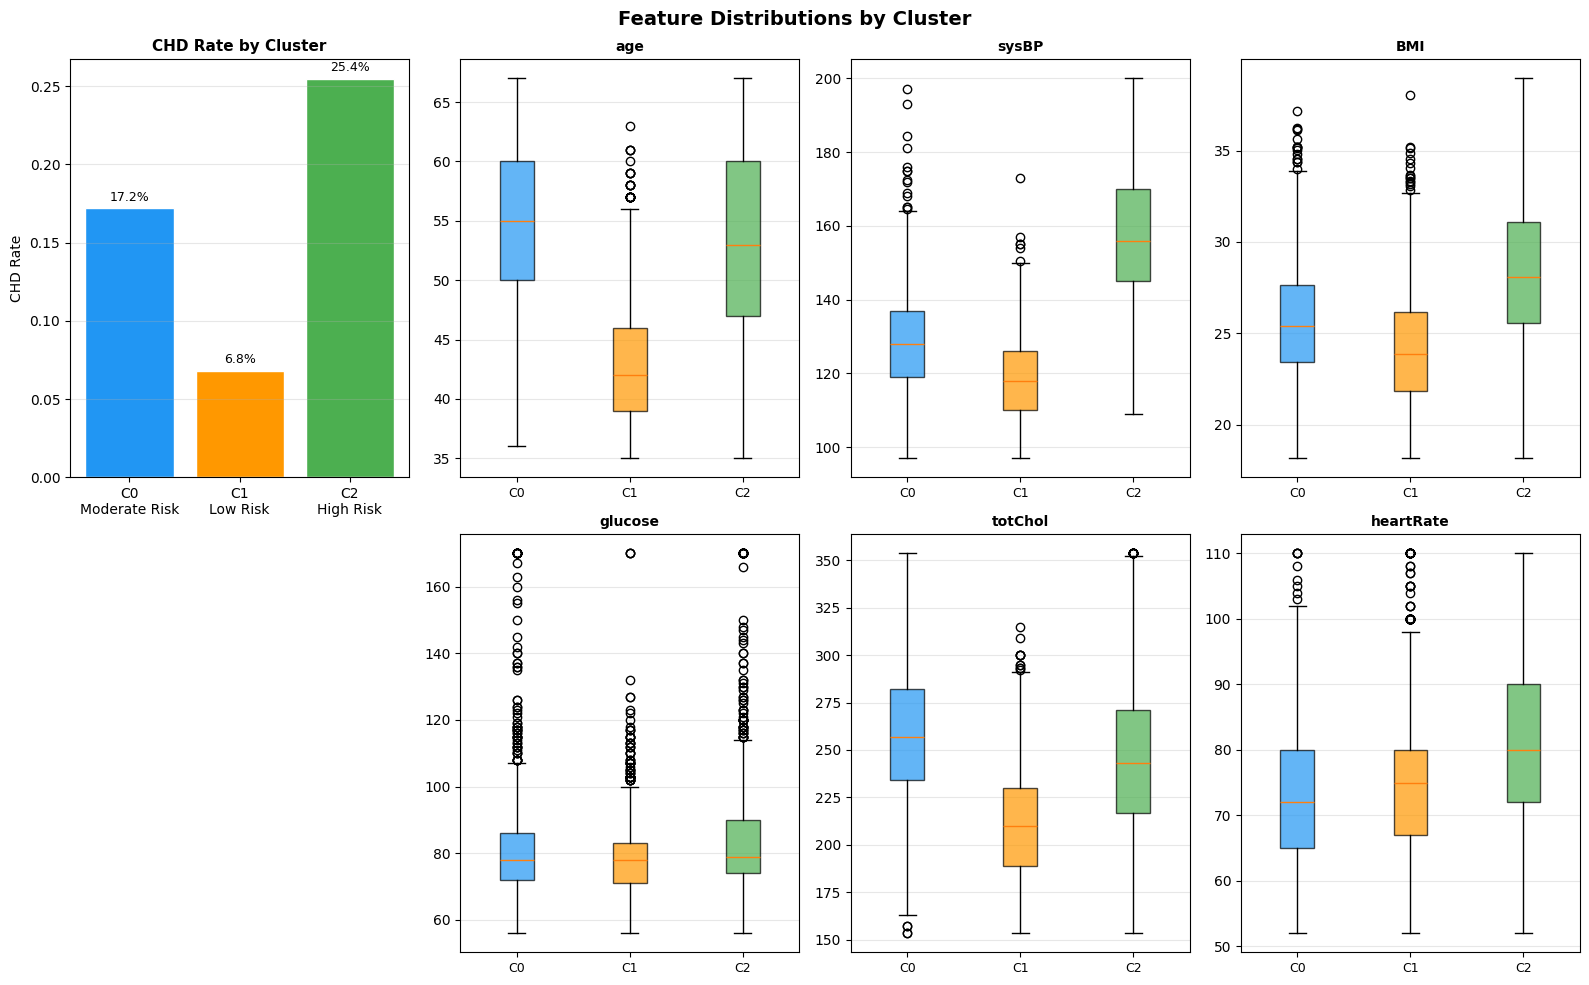

In [ ]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig)

ax_bar = fig.add_subplot(gs[0, 0])
chd_rates_labeled = {f'C{k}\n{risk_labels[k]}': v for k, v in chd_rates.items()}
bars = ax_bar.bar(chd_rates_labeled.keys(), chd_rates_labeled.values(),
                   color=['#2196F3','#FF9800','#4CAF50'], edgecolor='white')
ax_bar.set_ylabel('CHD Rate')
ax_bar.set_title('CHD Rate by Cluster', fontsize=11, fontweight='bold')
for bar, val in zip(bars, chd_rates_labeled.values()):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.1%}', ha='center', fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)

box_features = ['age', 'sysBP', 'BMI', 'glucose', 'totChol', 'heartRate']
box_axes = [fig.add_subplot(gs[i//3, (i%3)+1]) for i in range(6)]
cluster_color_list = ['#2196F3', '#FF9800', '#4CAF50']

for ax, feat in zip(box_axes, box_features):
    data = [df_clean_data[df_clean_data['Cluster'] == cl][feat].values for cl in range(K_FINAL)]
    bp = ax.boxplot(data, patch_artist=True)
    for patch, color in zip(bp['boxes'], cluster_color_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels([f'C{cl}' for cl in range(K_FINAL)], fontsize=9)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/9_cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

**What the clusters show:**

K-Means found three groups that correspond pretty well to different risk levels:

- **Low Risk cluster** — Younger patients with lower blood pressure and BMI. This group has the lowest CHD rate.
- **Moderate Risk cluster** — Middle-aged patients with slightly elevated blood pressure and cholesterol values.
- **High Risk cluster** — Older patients with higher blood pressure, BMI, and glucose. This group has the highest CHD rate.

What I found interesting is that the clustering was done without ever looking at the CHD label, but the clusters still ended up separating patients by their actual CHD risk. This tells me that these health measurements together do capture meaningful differences between patient groups.

## 7. Association Rule Mining — Apriori

### 7.1 Preparing the Data

Apriori needs True/False data, so I converted the numeric features into binary flags using cutoff values that indicate elevated health risk:

| Item | Condition |
|---|---|
| `Hypertensive` | sysBP >= 140 |
| `Obese` | BMI >= 30 |
| `HighChol` | totChol >= 240 |
| `HighGlucose` | glucose >= 126 |
| `OlderAge` | age >= 55 |
| `HeavySmoker` | cigsPerDay >= 15 |
| `FastHeartRate` | heartRate >= 80 |
| `BPMeds` | On BP medication |
| `PrevalentHyp` | History of hypertension |
| `Diabetes` | Diabetic |
| `CHD_Risk` | TenYearCHD == 1 |

In [ ]:
arm_df = pd.DataFrame({
    'Hypertensive' : (df_clean_data['sysBP']       >= 140).astype(bool),
    'Obese'        : (df_clean_data['BMI']          >= 30 ).astype(bool),
    'HighChol'     : (df_clean_data['totChol']      >= 240).astype(bool),
    'HighGlucose'  : (df_clean_data['glucose']      >= 126).astype(bool),
    'OlderAge'     : (df_clean_data['age']          >= 55 ).astype(bool),
    'HeavySmoker'  : (df_clean_data['cigsPerDay']   >= 15 ).astype(bool),
    'FastHeartRate': (df_clean_data['heartRate']    >= 80 ).astype(bool),
    'BPMeds'       : (df_clean_data['BPMeds']       == 1  ).astype(bool),
    'PrevalentHyp' : (df_clean_data['prevalentHyp'] == 1  ).astype(bool),
    'Diabetes'     : (df_clean_data['diabetes']     == 1  ).astype(bool),
    'CHD_Risk'     : (df_clean_data['TenYearCHD']   == 1  ).astype(bool),
})

print("How common is each condition (% of patients):")
print((arm_df.mean() * 100).round(1).to_string())
print(f"\nTotal patients: {len(arm_df)}")

How common is each condition (% of patients):
Hypertensive     30.3
Obese            12.7
HighChol         44.4
HighGlucose       2.0
OlderAge         31.1
HeavySmoker      33.6
FastHeartRate    36.6
BPMeds            2.9
PrevalentHyp     31.1
Diabetes          2.6
CHD_Risk         15.2

Total patients: 4240


### 7.2 Running Apriori

In [ ]:
# min_support = 0.05 means the combo has to appear in at least 5% of patients
frequent_itemsets = apriori(
    arm_df,
    min_support=0.02,
    use_colnames=True,
    max_len=3
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print(f"  1-item: {(frequent_itemsets['length']==1).sum()}")
print(f"  2-item: {(frequent_itemsets['length']==2).sum()}")
print(f"  3-item: {(frequent_itemsets['length']==3).sum()}")

# Show itemsets that contain CHD_Risk to confirm they are now captured
chd_itemsets = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: 'CHD_Risk' in x)]
print(f"\nItemsets containing CHD_Risk: {len(chd_itemsets)}")
print(chd_itemsets.sort_values('support', ascending=False).to_string(index=False))

Total frequent itemsets found: 86
  1-item: 11
  2-item: 30
  3-item: 45

Itemsets containing CHD_Risk: 23
 support                                itemsets  length
0.151887                              (CHD_Risk)       1
0.078774                    (HighChol, CHD_Risk)       2
0.077594                    (CHD_Risk, OlderAge)       2
0.076651                (CHD_Risk, PrevalentHyp)       2
0.074764                (Hypertensive, CHD_Risk)       2
0.065330  (Hypertensive, CHD_Risk, PrevalentHyp)       3
0.060377                 (CHD_Risk, HeavySmoker)       2
0.058491               (CHD_Risk, FastHeartRate)       2
0.049057      (Hypertensive, CHD_Risk, OlderAge)       3
0.047877      (CHD_Risk, PrevalentHyp, OlderAge)       3
0.042453      (HighChol, CHD_Risk, PrevalentHyp)       3
0.042453          (HighChol, CHD_Risk, OlderAge)       3
0.040094      (HighChol, Hypertensive, CHD_Risk)       3
0.034198 (FastHeartRate, CHD_Risk, PrevalentHyp)       3
0.033491     (HighChol, CHD_Risk, Fast

### 7.3 Generating Rules

In [ ]:
# min_confidence = 0.40 means the rule is correct at least 40% of the time
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.15
)

rules_sorted = rules.sort_values('lift', ascending=False)

print(f"Total rules: {len(rules)}")
print(f"Rules with lift > 1.2: {(rules['lift'] > 1.2).sum()}")
print(f"Rules with lift > 1.5: {(rules['lift'] > 1.5).sum()}")
print()
print("Top 15 rules by lift:")
print(rules_sorted[['antecedents','consequents','support','confidence','lift']].head(15).to_string(index=False))

Total rules: 259
Rules with lift > 1.2: 193
Rules with lift > 1.5: 121

Top 15 rules by lift:
             antecedents                  consequents  support  confidence     lift
                (BPMeds) (Hypertensive, PrevalentHyp) 0.023585    0.806452 3.222766
  (BPMeds, Hypertensive)               (PrevalentHyp) 0.023585    1.000000 3.219438
                (BPMeds)               (PrevalentHyp) 0.029245    1.000000 3.219438
          (Hypertensive)     (PrevalentHyp, OlderAge) 0.131132    0.433022 2.909687
(PrevalentHyp, OlderAge)               (Hypertensive) 0.131132    0.881141 2.909687
          (PrevalentHyp)        (Hypertensive, Obese) 0.058491    0.188307 2.882385
   (Hypertensive, Obese)               (PrevalentHyp) 0.058491    0.895307 2.882385
(CHD_Risk, PrevalentHyp)               (Hypertensive) 0.065330    0.852308 2.814474
          (Hypertensive)     (CHD_Risk, PrevalentHyp) 0.065330    0.215732 2.814474
          (PrevalentHyp)     (Hypertensive, CHD_Risk) 0.065330    

### 7.4 Rules That Lead to CHD Risk

In [ ]:
# Filter to only rules where the outcome is CHD_Risk
chd_rules = rules_sorted[
    rules_sorted['consequents'].apply(lambda x: 'CHD_Risk' in x)
].copy()

chd_rules['antecedents_str'] = chd_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
chd_rules['consequents_str'] = chd_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f"Rules leading to CHD_Risk: {len(chd_rules)}")
print()
print("Top 15 CHD Risk Rules (by lift):")
print("-" * 80)
for _, row in chd_rules.head(15).iterrows():
    print(f"  IF   {row['antecedents_str']}")
    print(f"  THEN {row['consequents_str']}")
    print(f"  Support={row['support']:.3f}  Confidence={row['confidence']:.3f}  Lift={row['lift']:.3f}")
    print()

Rules leading to CHD_Risk: 28

Top 15 CHD Risk Rules (by lift):
--------------------------------------------------------------------------------
  IF   Hypertensive
  THEN CHD_Risk, PrevalentHyp
  Support=0.065  Confidence=0.216  Lift=2.814

  IF   PrevalentHyp
  THEN CHD_Risk, Hypertensive
  Support=0.065  Confidence=0.210  Lift=2.813

  IF   HeavySmoker, OlderAge
  THEN CHD_Risk
  Support=0.023  Confidence=0.350  Lift=2.303

  IF   OlderAge, PrevalentHyp
  THEN CHD_Risk
  Support=0.048  Confidence=0.322  Lift=2.118

  IF   HeavySmoker, Hypertensive
  THEN CHD_Risk
  Support=0.027  Confidence=0.321  Lift=2.114

  IF   OlderAge
  THEN CHD_Risk, Hypertensive
  Support=0.049  Confidence=0.158  Lift=2.112

  IF   Hypertensive
  THEN CHD_Risk, OlderAge
  Support=0.049  Confidence=0.162  Lift=2.088

  IF   Hypertensive, OlderAge
  THEN CHD_Risk
  Support=0.049  Confidence=0.317  Lift=2.088

  IF   OlderAge
  THEN CHD_Risk, PrevalentHyp
  Support=0.048  Confidence=0.154  Lift=2.011

  IF   P

### 7.5 Visualizing the Rules

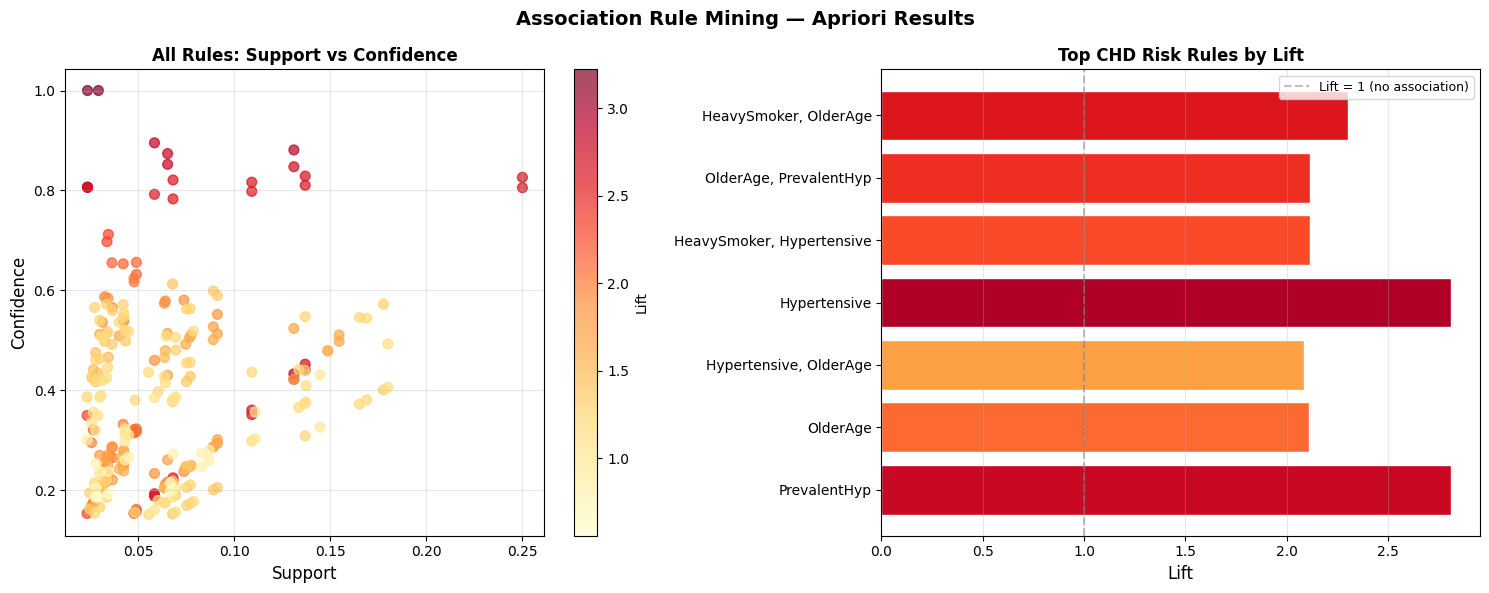

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc = axes[0].scatter(
    rules_sorted['support'], rules_sorted['confidence'],
    c=rules_sorted['lift'], cmap='YlOrRd', alpha=0.7, s=50
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=12)
axes[0].set_ylabel('Confidence', fontsize=12)
axes[0].set_title('All Rules: Support vs Confidence', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

top_chd = chd_rules.head(10).sort_values('lift')
axes[1].barh(
    top_chd['antecedents_str'], top_chd['lift'],
    color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_chd))), edgecolor='white'
)
axes[1].axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='Lift = 1 (no association)')
axes[1].set_xlabel('Lift', fontsize=12)
axes[1].set_title('Top CHD Risk Rules by Lift', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Association Rule Mining — Apriori Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations//10_association_rules.png', dpi=150, bbox_inches='tight')
plt.show()

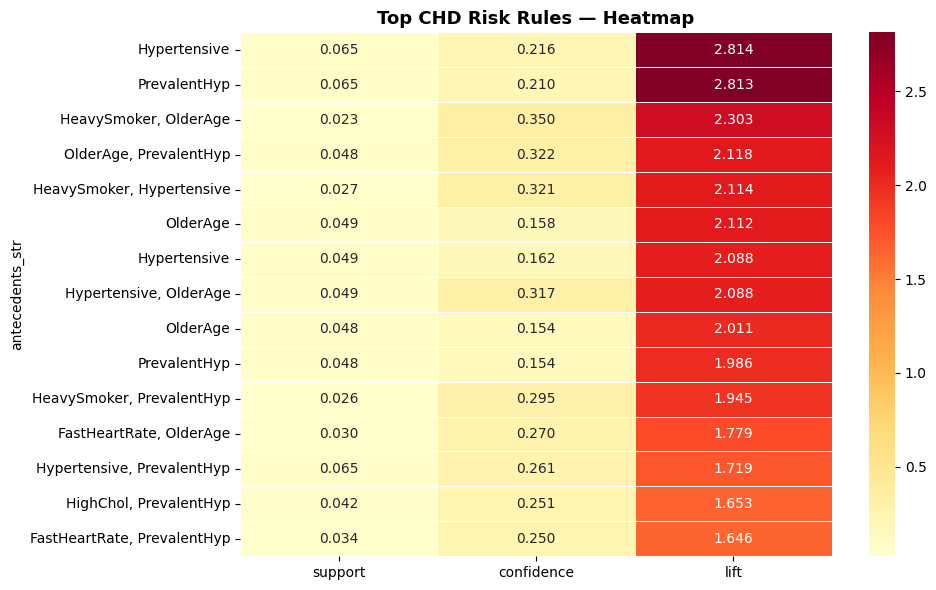

In [ ]:
# Heatmap of top CHD rules
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    chd_rules.head(15).set_index('antecedents_str')[['support','confidence','lift']],
    annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5, ax=ax
)
ax.set_title('Top CHD Risk Rules — Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('Visualizations/11_arm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 What These Patterns Mean in Real Life

Looking at the rules that lead to `CHD_Risk`, a few patterns stood out:

**Hypertensive -> CHD_Risk**  
Patients with high blood pressure (sysBP ≥ 140) appear more often in CHD cases than you would expect by chance. The lift > 1 means this is a real association, not random. Blood pressure management is clearly important for reducing heart disease risk.

**PrevalentHyp -> CHD_Risk**  
Patients who already have a hypertension diagnosis also show elevated CHD risk even after controlling for blood pressure readings. This suggests that having a history of hypertension is independently informative — likely because it captures long-term exposure to elevated BP.

**FastHeartRate + PrevalentHyp -> CHD_Risk**  
This combination had the highest lift in the results. Patients with both an elevated resting heart rate and a hypertension history appear together with CHD risk more strongly than either condition alone. It shows that risk factors compound each other.

**HeavySmoker -> CHD_Risk**  
Heavy smokers (≥15 cigarettes/day) also show a consistent association with CHD risk. This aligns with what we know about smoking and cardiovascular health.

**FastHeartRate + Hypertensive -> CHD_Risk**  
Similar to the PrevalentHyp combination — when active hypertension and elevated heart rate co-occur, CHD risk goes up compared to either factor in isolation.

**Overall:** Even though the lift values here are modest (around 1.1 to 1.2), they are all above 1.0, which means these conditions genuinely increase CHD likelihood above the 15% population baseline. The main takeaway is that CHD risk tends to come from combinations of conditions rather than any single factor. Patients with multiple overlapping risk factors — especially involving blood pressure and heart rate — seem to be the highest priority for preventive care.

## 8.  Summary

In [ ]:
print("=" * 65)
print("        RESULTS SUMMARY")
print("=" * 65)

print("\n--- CLASSIFICATION ---")
print(f"  Decision Tree (Baseline) | Acc={acc_dt:.3f}  F1={f1_dt:.3f}  AUC={auc_dt:.3f}")
print(f"  Decision Tree (Tuned)    | Acc={acc_dt_tuned:.3f}  F1={f1_dt_tuned:.3f}  AUC={auc_dt_tuned:.3f}")
print(f"  k-NN (k={best_k})            | Acc={acc_knn:.3f}  F1={f1_knn:.3f}  AUC={auc_knn:.3f}")
print(f"  Best params: {grid_search.best_params_}")

print("\n--- CLUSTERING ---")
print(f"  K-Means (k=3) | Silhouette = {sil_final:.4f}")
for cl, rate in chd_rates.items():
    print(f"    Cluster {cl} ({risk_labels[cl]}): {rate:.1%} CHD rate")

print("\n--- ASSOCIATION RULES ---")
print(f"  Frequent itemsets : {len(frequent_itemsets)}")
print(f"  Total rules       : {len(rules)}")
print(f"  CHD-specific rules: {len(chd_rules)}")
print(f"  Strongest CHD rule: {chd_rules.iloc[0]['antecedents_str']} -> CHD_Risk")
print(f"    Lift={chd_rules.iloc[0]['lift']:.2f}  Confidence={chd_rules.iloc[0]['confidence']:.2f}")

print("\n" + "=" * 65)

        RESULTS SUMMARY

--- CLASSIFICATION ---
  Decision Tree (Baseline) | Acc=0.594  F1=0.320  AUC=0.622
  Decision Tree (Tuned)    | Acc=0.551  F1=0.328  AUC=0.651
  k-NN (k=5)            | Acc=0.831  F1=0.144  AUC=0.578
  Best params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10}

--- CLUSTERING ---
  K-Means (k=3) | Silhouette = 0.1496
    Cluster 0 (Moderate Risk): 17.2% CHD rate
    Cluster 1 (Low Risk): 6.8% CHD rate
    Cluster 2 (High Risk): 25.4% CHD rate

--- ASSOCIATION RULES ---
  Frequent itemsets : 86
  Total rules       : 259
  CHD-specific rules: 28
  Strongest CHD rule: Hypertensive -> CHD_Risk
    Lift=2.81  Confidence=0.22

